# Exercício prático 1 
## Análise de dados: Finanças Pessoais


### Passo a passo:
1. 🧹 **Limpeza dos dados**
2. 📊 **Análise exploratória**
3. 📈 **Visualizações informativas**
4. 🔍 **Identificação de insights**
5. 📋 **Conclusões e recomendações**

# Escolhendo o dataset

# Carregando e Preparando os Dados
1. ***Carregar*** o dataset
2. ***Explorar*** a estrutura dos dados
3. ***Limpar*** valores ausentes
4. ***Preparar*** para análise

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Carregando dataset Finaças Pessoais')
df = pd.read_csv('https://raw.githubusercontent.com/lucasalmo/lia1_2026_1/refs/heads/main/Entregas%20-%20Lucas%20Almeida%20Moreira/student_performance_prediction_dataset-2.csv')

print('Informações básicas do dataset:')
print(f'Dimensões: {df.shape}')
print(f'Colunas: {list(df.columns)}')

print('\nUm pouco sobre o Dataset:')
df.tail(50)

Carregando dataset Finaças Pessoais
Informações básicas do dataset:
Dimensões: (300000, 25)
Colunas: ['student_id', 'age', 'gender', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars', 'final_grade', 'grade_category', 'pass_fail']

Um pouco sobre o Dataset:


,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
299950,299951,20,Male,2.013538,90.062262,9.228039,66.119051,7.111819,3.283820,1.565922,...,4.067053,Medium,Bachelor,Yes,Laptop,Public,Debate,47.101386,F,Fail
299951,299952,17,Female,3.578731,100.000000,7.321820,82.468124,6.483100,4.482805,0.344110,...,3.058793,Medium,High School,Yes,Mobile,Public,Debate,44.556579,F,Fail
299952,299953,15,Female,3.699353,72.855585,7.090717,73.061462,8.152851,6.477744,0.873508,...,5.634313,Medium,PhD,Yes,Mobile,Public,Music,56.969432,D,Pass
299953,299954,16,Female,3.813079,76.074741,7.031734,69.695517,7.703404,3.987318,0.893974,...,2.272317,Low,High School,Yes,Laptop,Public,Coding Club,41.223311,F,Fail
299954,299955,15,Male,6.946142,98.498695,7.812510,51.166409,8.296231,2.977851,0.836176,...,0.455761,Low,Master,Yes,Tablet,Private,Sports,57.916423,D,Pass
299955,299956,18,Male,5.923693,66.751779,8.176426,45.267833,6.231487,2.850199,0.701370,...,1.454774,Medium,High School,Yes,Mobile,Public,Debate,35.941721,F,Fail
299956,299957,17,Male,3.355729,95.318548,7.086528,92.870127,4.970659,3.059914,2.786894,...,2.917954,Medium,Bachelor,Yes,NaN,Private,Sports,59.881277,D,Pass
299957,299958,15,Male,5.977678,99.750727,5.759932,63.520611,7.865581,5.382897,0.368106,...,4.218420,High,High School,Yes,Mobile,Public,NaN,56.997952,D,Pass
299958,299959,20,Male,1.020464,86.439695,6.171502,56.469187,8.242073,3.699952,1.916902,...,1.906925,Medium,Master,Yes,Laptop,Public,NaN,29.976003,F,Fail
299959,299960,20,Male,5.344994,88.326482,6.347041,70.708939,7.941857,1.786222,1.584878,...,0.345213,Low,Bachelor,Yes,Laptop,Private,Sports,68.834491,C,Pass


## Limpando os dados

In [85]:
print('Verificando dados ausentes:')
da = df.isnull().sum()
print(da[da > 0])

# Limpando os dados
print('Realizando limpeza dos dados')

# 1. Removendo coluna 'loan_type' pode ter muitos dados faltando
if 'loan_type' in df.columns:
    df = df.drop('loan_type', axis=1)


Verificando dados ausentes:
loan_type    19429
dtype: int64
Realizando limpeza dos dados


In [68]:
# Limpando os dados
df_limpo = df.copy()

# 1. Removendo linhas com grau de escolaridade e gênero que estão como outro para ter resultados mais precisos
#df_limpo = df_limpo[df_limpo['education_level'] != 'Other']

df_limpo.head(50)

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07
5,U00006,62,Male,Master,Employed,Student,4051.00,2244.42,194901.41,Yes,Car,407915.25,12,38219.81,22.21,9.43,718,4.01,North America,2025-02-12
6,U00007,22,Female,Master,Student,Accountant,983.69,332.62,37522.56,Yes,Car,296057.60,180,6773.29,26.95,6.89,761,3.18,Asia,2024-06-01
7,U00008,18,Female,Bachelor,Employed,Accountant,6199.29,4503.15,89107.54,No,NaN,0.00,0,0.00,0.00,0.00,540,1.20,Africa,2024-03-17
8,U00009,49,Female,High School,Self-employed,Doctor,4271.51,3062.12,451923.96,No,NaN,0.00,0,0.00,0.00,0.00,327,8.82,Africa,2023-05-02
9,U00010,61,Male,Master,Employed,Student,5216.18,4369.36,203320.50,Yes,Education,324197.37,360,6782.37,25.09,1.30,558,3.25,Asia,2024-11-23


## Problema a ser resolvido
***O grau de escolaridade influencia a probabilidade de uma pessoa fazer empréstimo?***

## Visualizando os dados

In [53]:
# Verificando dados por categoria de gênero
df['gender'].value_counts()

gender
Male      15595
Female    15550
Other      1279
Name: count, dtype: int64

In [71]:
ordem = ['High School', 'Bachelor', 'Master', 'PhD', 'Other']

df_limpo["education_level"] = pd.Categorical(df_limpo["education_level"], categories=ordem, ordered=True)

In [70]:
pd.crosstab(df_limpo['education_level'], df_limpo['has_loan'])

has_loan,No,Yes
education_level,,
High School,3807,2649
Bachelor,7890,5148
Master,5783,3890
PhD,995,643
Other,954,665


In [72]:
# Em percentual
pd.crosstab(
    df_limpo['education_level'],
    df_limpo['has_loan'],
    normalize='index'
)

has_loan,No,Yes
education_level,,
High School,0.589684,0.410316
Bachelor,0.605154,0.394846
Master,0.597850,0.402150
PhD,0.607448,0.392552
Other,0.589253,0.410747


In [73]:
df_limpo.groupby("education_level")["has_loan"].value_counts(normalize=True)

/tmp/ipykernel_153561/1790150494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_limpo.groupby("education_level")["has_loan"].value_counts(normalize=True)


education_level  has_loan
High School      No          0.589684
                 Yes         0.410316
Bachelor         No          0.605154
                 Yes         0.394846
Master           No          0.597850
                 Yes         0.402150
PhD              No          0.607448
                 Yes         0.392552
Other            No          0.589253
                 Yes         0.410747
Name: proportion, dtype: float64

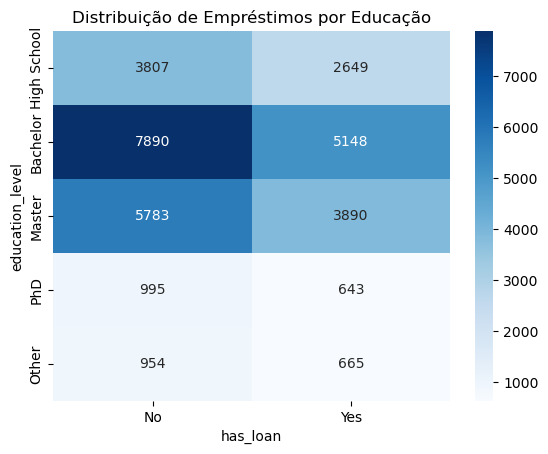

In [74]:
tabela = pd.crosstab(df_limpo["education_level"], df_limpo["has_loan"])

sns.heatmap(tabela, annot=True, fmt="d", cmap="Blues")

plt.title("Distribuição de Empréstimos por Educação")

plt.show()

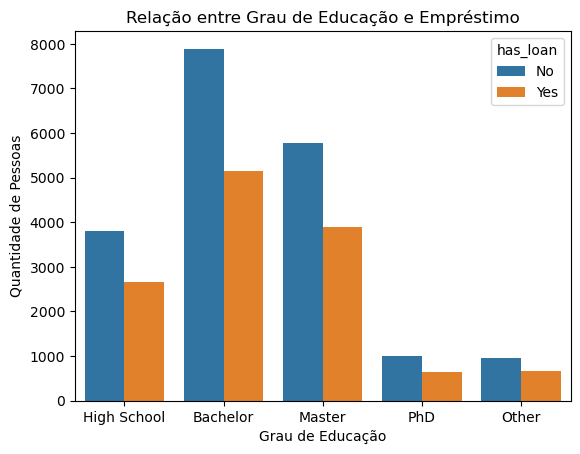

In [78]:
sns.countplot(data=df_limpo, x="education_level", hue="has_loan")

plt.title("Relação entre Grau de Educação e Empréstimo")
plt.xlabel("Grau de Educação")
plt.ylabel("Quantidade de Pessoas")

plt.show()

In [ ]:
# 